In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_methanation_data(file_path):
    df_raw = pd.read_json(file_path, orient="index")
    df = pd.DataFrame()

    for col in df_raw.columns:
        df[f"{col}_{df_raw[col].iloc[0]['units'].replace(' ', '_').replace('/', '_per_')}"] = df_raw[col].apply(lambda x: x['value'])

    df.columns = df.columns.str.replace('__', '_')
    for col in df.columns:
        if col.startswith("moles_") and "_mole" in col:
            new_col_name = col.replace("moles_", "")
            df.rename(columns={col: new_col_name}, inplace=True)

    return df

df = parse_methanation_data("methanation_sim_level_1_status.json")

In [2]:
def moles_to_grams(moles, molar_mass):
    return moles * molar_mass

df["CO2_g"] = moles_to_grams(df["CO2_mole"], 44.01)
df["H2_g"] = moles_to_grams(df["H2_mole"], 2.016)
df["CH4_g"] = moles_to_grams(df["CH4_mole"], 16.04)
df["H2O_g"] = moles_to_grams(df["H2O_mole"], 18.015)

df["CO2_consumption_rate_g_per_s"] = df["CO2_g"].diff() / df["time_elapsed_second"].diff()
df["H2_consumption_rate_g_per_s"] = df["H2_g"].diff() / df["time_elapsed_second"].diff()
df["CH4_production_rate_g_per_s"] = df["CH4_g"].diff() / df["time_elapsed_second"].diff()
df["H2O_production_rate_g_per_s"] = df["H2O_g"].diff() / df["time_elapsed_second"].diff()

df

,time_elapsed_second,rate_constant_mole_per_second,current_rate_mole_per_second,CO2_mole,H2_mole,CH4_mole,H2O_mole,total_consumed_CO2_mole,total_consumed_H2_mole,total_produced_CH4_mole,total_produced_H2O_mole,CO2_g,H2_g,CH4_g,H2O_g,CO2_consumption_rate_g_per_s,H2_consumption_rate_g_per_s,CH4_production_rate_g_per_s,H2O_production_rate_g_per_s
0,0.0,0.5,0.5,10.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,440.100,100.80,0.0,0.000,NaN,NaN,NaN,NaN
5,5.0,0.5,0.5,7.5,40.0,2.5,5.0,2.5,10.0,2.5,5.0,330.075,80.64,40.1,90.075,-22.005,-4.032,8.02,18.015
10,10.0,0.5,0.5,5.0,30.0,5.0,10.0,5.0,20.0,5.0,10.0,220.050,60.48,80.2,180.150,-22.005,-4.032,8.02,18.015
15,15.0,0.5,0.5,2.5,20.0,7.5,15.0,7.5,30.0,7.5,15.0,110.025,40.32,120.3,270.225,-22.005,-4.032,8.02,18.015
20,20.0,0.5,0.5,0.0,10.0,10.0,20.0,10.0,40.0,10.0,20.0,0.000,20.16,160.4,360.300,-22.005,-4.032,8.02,18.015
25,25.0,0.5,0.5,0.0,10.0,10.0,20.0,10.0,40.0,10.0,20.0,0.000,20.16,160.4,360.300,0.000,0.000,0.00,0.000
30,30.0,0.5,0.5,0.0,10.0,10.0,20.0,10.0,40.0,10.0,20.0,0.000,20.16,160.4,360.300,0.000,0.000,0.00,0.000


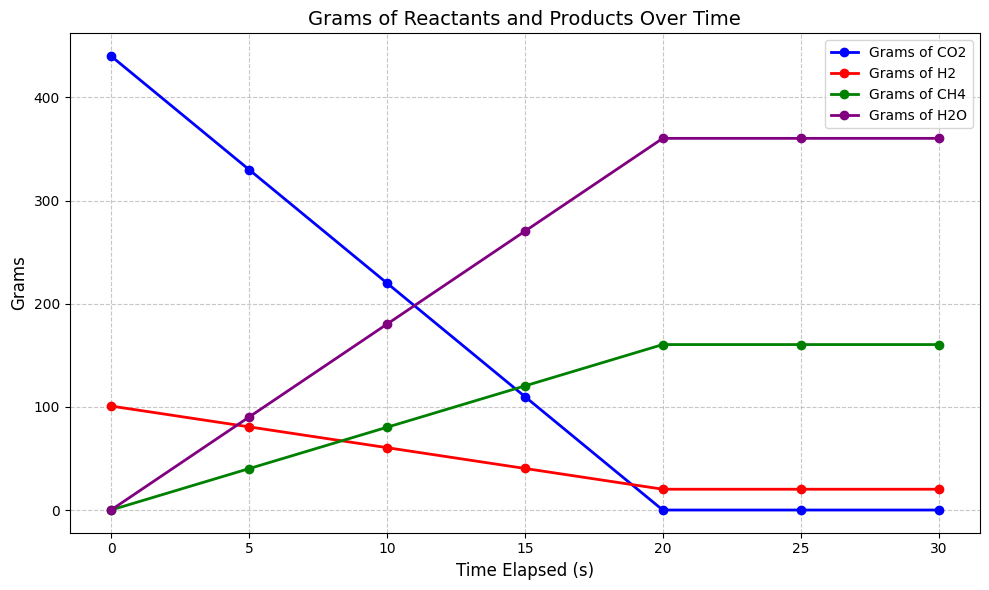

In [3]:
# plt.figure(figsize=(10, 6))
# plt.plot(df["time_elapsed"], df["moles_CO2"], label="Moles of CO2", color="blue", linewidth=2, marker="o")
# plt.plot(df["time_elapsed"], df["moles_H2"], label="Moles of H2", color="red", linewidth=2, marker="o")
# plt.plot(df["time_elapsed"], df["moles_CH4"], label="Moles of CH4", color="green", linewidth=2, marker="o")
# plt.plot(df["time_elapsed"], df["moles_H2O"], label="Moles of H2O", color="purple", linewidth=2, marker="o")
# plt.title("Moles of Reactants and Products Over Time", fontsize=14)
# plt.xlabel("Time Elapsed (s)", fontsize=12)
# plt.ylabel("Moles", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df["time_elapsed_second"], df["CO2_g"], label="Grams of CO2", color="blue", linewidth=2, marker="o")
plt.plot(df["time_elapsed_second"], df["H2_g"], label="Grams of H2", color="red", linewidth=2, marker="o")
plt.plot(df["time_elapsed_second"], df["CH4_g"], label="Grams of CH4", color="green", linewidth=2, marker="o")
plt.plot(df["time_elapsed_second"], df["H2O_g"], label="Grams of H2O", color="purple", linewidth=2, marker="o")
plt.title("Grams of Reactants and Products Over Time", fontsize=14)
plt.xlabel("Time Elapsed (s)", fontsize=12)
plt.ylabel("Grams", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("static/images/methanation_sim_level_1_moles_to_grams.png", dpi=300)
plt.show()

In [4]:
file_path = "methanation_sim_level_2_status.json"

df_raw = pd.read_json(file_path, orient="index")
df = pd.DataFrame()

for col in df_raw.columns:
    if isinstance(df_raw[col].iloc[0], dict) and 'units' in df_raw[col].iloc[0]:
        unit_str = df_raw[col].iloc[0]['units'].replace(' ', '_').replace('/', '_per_').replace('**', 'pow')
        df[f"{col}_{unit_str}"] = df_raw[col].apply(lambda x: x['value'] if isinstance(x, dict) else x)
    else:
        df[col] = df_raw[col]

df.columns = df.columns.str.replace('__', '_')
df.columns = df.columns.str.replace('pow_3', 'cubed')
df.columns = df.columns.str.replace('pow_2', 'squared')
for col in df.columns:
    if col.startswith("moles_") and "_mole" in col:
        new_col_name = col.replace("moles_", "")
        df.rename(columns={col: new_col_name}, inplace=True)

df["CO2_g"] = moles_to_grams(df["CO2_mole"], 44.01)
df["H2_g"] = moles_to_grams(df["H2_mole"], 2.016)
df["CH4_g"] = moles_to_grams(df["CH4_mole"], 16.04)
df["H2O_g"] = moles_to_grams(df["H2O_mole"], 18.015)

df["CO2_consumption_rate_g_per_s"] = df["CO2_g"].diff() / df["time_elapsed_second"].diff()
df["H2_consumption_rate_g_per_s"] = df["H2_g"].diff() / df["time_elapsed_second"].diff()
df["CH4_production_rate_g_per_s"] = df["CH4_g"].diff() / df["time_elapsed_second"].diff()
df["H2O_production_rate_g_per_s"] = df["H2O_g"].diff() / df["time_elapsed_second"].diff()

In [5]:
df

,time_elapsed_second,rate_constant_mole_per_second,current_rate_meter_pow_12_per_mole_pow_4_per_second,CO2_mole,H2_mole,CH4_mole,H2O_mole,total_consumed_CO2_mole,total_consumed_H2_mole,total_produced_CH4_mole,...,inlet_flow_CO2_mole_per_second,inlet_flow_H2_mole_per_second,CO2_g,H2_g,CH4_g,H2O_g,CO2_consumption_rate_g_per_s,H2_consumption_rate_g_per_s,CH4_production_rate_g_per_s,H2O_production_rate_g_per_s
0,0.0,0.0,0.061746,10.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,440.100000,100.800000,0.000000,0.000000,NaN,NaN,NaN,NaN
5,5.0,0.0,0.061746,9.965075,49.860299,0.034925,0.069850,0.034925,0.139701,0.034925,...,1.993015,9.972060,438.562944,100.518364,0.560200,1.258353,-0.307411,-0.056327,0.112040,0.251671
10,10.0,0.0,0.061746,9.930656,49.722624,0.069344,0.138688,0.069344,0.277376,0.069344,...,0.993066,4.972262,437.048173,100.240811,1.112277,2.498462,-0.302954,-0.055511,0.110415,0.248022
15,15.0,0.0,0.061746,9.896731,49.586922,0.103269,0.206539,0.103269,0.413078,0.103269,...,0.659782,3.305795,435.555114,99.967236,1.656441,3.720796,-0.298612,-0.054715,0.108833,0.244467
20,20.0,0.0,0.061746,9.863286,49.453144,0.136714,0.273428,0.136714,0.546856,0.136714,...,0.493164,2.472657,434.083213,99.697538,2.192894,4.925809,-0.294380,-0.053940,0.107291,0.241002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3575,3575.0,0.0,0.061746,4.894363,29.577451,5.105637,10.211274,5.105637,20.422549,5.105637,...,0.001369,0.008273,215.400909,59.628142,81.894420,183.956107,-0.018574,-0.003403,0.006770,0.015206
3580,3580.0,0.0,0.061746,4.892256,29.569024,5.107744,10.215488,5.107744,20.430976,5.107744,...,0.001367,0.008260,215.308183,59.611152,81.928215,184.032019,-0.018545,-0.003398,0.006759,0.015182
3585,3585.0,0.0,0.061746,4.890152,29.560609,5.109848,10.219695,5.109848,20.439391,5.109848,...,0.001364,0.008246,215.215603,59.594188,81.961957,184.107813,-0.018516,-0.003393,0.006748,0.015159
3590,3590.0,0.0,0.061746,4.888052,29.552208,5.111948,10.223896,5.111948,20.447792,5.111948,...,0.001362,0.008232,215.123167,59.577251,81.995646,184.183487,-0.018487,-0.003387,0.006738,0.015135


In [6]:
df.columns

Index(['time_elapsed_second', 'rate_constant_mole_per_second',
       'current_rate_meter_pow_12_per_mole_pow_4_per_second', 'CO2_mole',
       'H2_mole', 'CH4_mole', 'H2O_mole', 'total_consumed_CO2_mole',
       'total_consumed_H2_mole', 'total_produced_CH4_mole',
       'total_produced_H2O_mole', 'reactor_type', 'reactor_volume_meter_cubed',
       'temperature_kelvin', 'activation_energy_joule_per_mole',
       'pre_exponential_meter_pow_12_per_mole_pow_4_per_second',
       'volumetric_flow_rate_meter_cubed_per_second',
       'arrhenius_rate_constant_meter_pow_12_per_mole_pow_4_per_second',
       'current_reaction_rate_mole_per_meter_cubed_per_second',
       'inlet_flow_CO2_mole_per_second', 'inlet_flow_H2_mole_per_second',
       'CO2_g', 'H2_g', 'CH4_g', 'H2O_g', 'CO2_consumption_rate_g_per_s',
       'H2_consumption_rate_g_per_s', 'CH4_production_rate_g_per_s',
       'H2O_production_rate_g_per_s'],
      dtype='object')

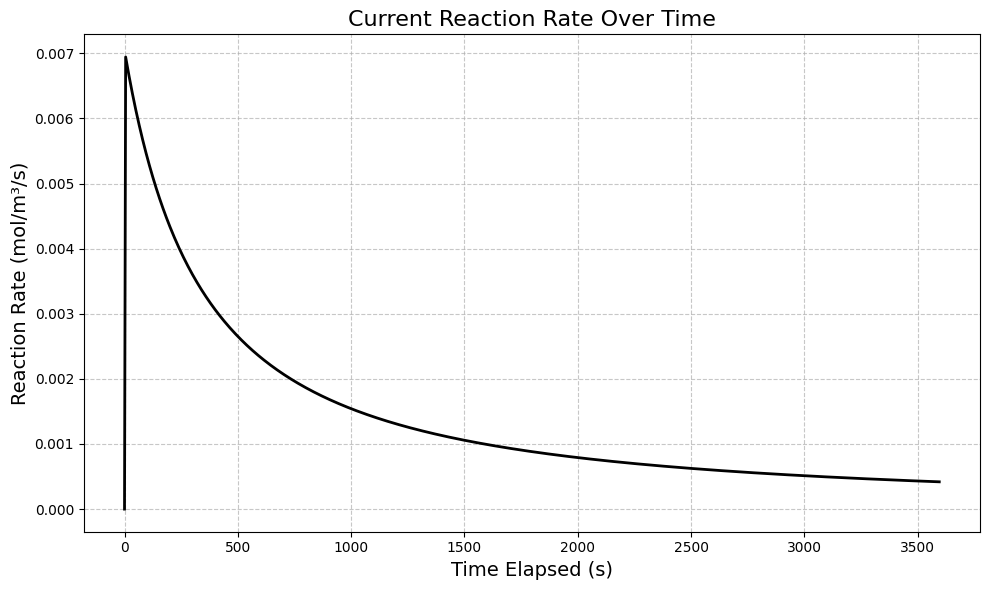

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.current_reaction_rate_mole_per_meter_cubed_per_second, color='black', linewidth=2)
plt.title("Current Reaction Rate Over Time", fontsize=16)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Reaction Rate (mol/m³/s)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig("static/images/current_reaction_rate_over_time.png", dpi=300)
plt.show()

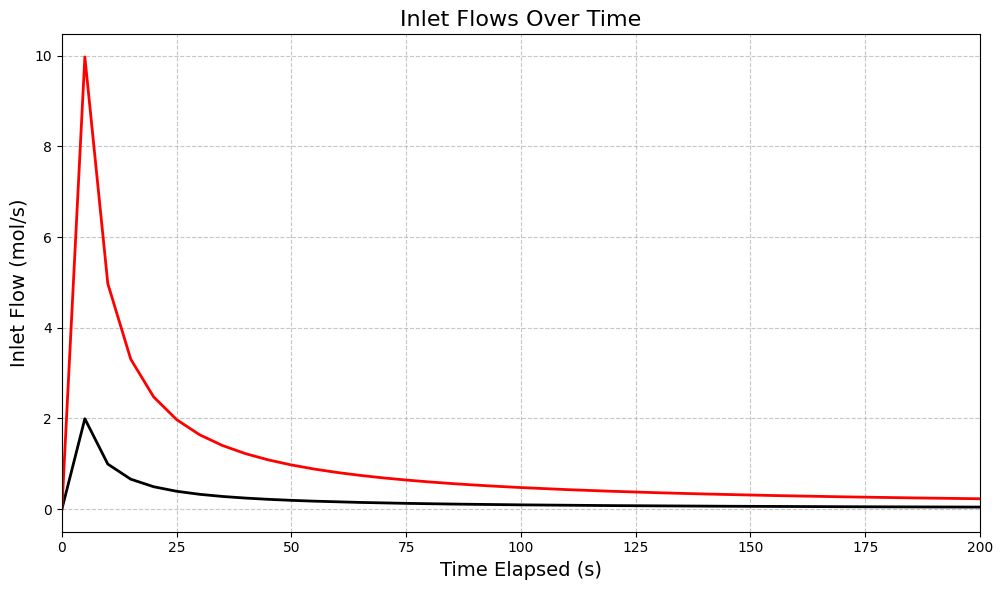

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.inlet_flow_CO2_mole_per_second, color='black', linewidth=2, label="CO2 Inlet Flow")
plt.plot(df.index, df.inlet_flow_H2_mole_per_second, color='red', linewidth=2, label="H2 Inlet Flow")
plt.title("Inlet Flows Over Time", fontsize=16)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Inlet Flow (mol/s)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(0, 200)
# plt.savefig("static/images/inlet_flows_over_time.png", dpi=300)
plt.show()


/var/folders/fh/ct4dhs1d7pq42n_96f1hwzkw0000gn/T/ipykernel_46833/885931786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_df["time_elapsed_minutes"] = sampled_df["time_elapsed_second"] / 60


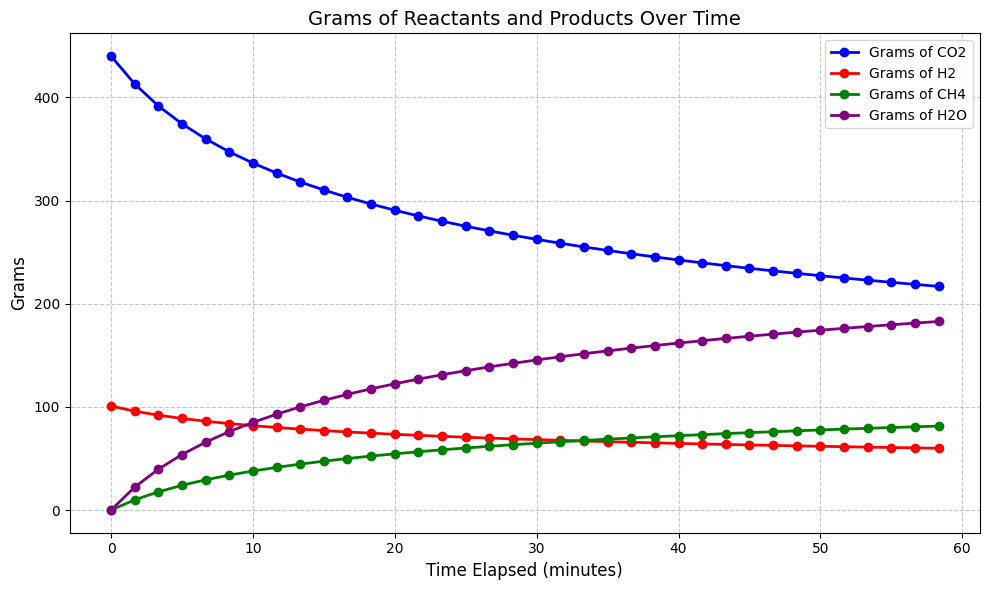

In [9]:
plt.figure(figsize=(10, 6))
sampled_df = df[::20]
sampled_df["time_elapsed_minutes"] = sampled_df["time_elapsed_second"] / 60
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["CO2_g"], label="Grams of CO2", color="blue", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["H2_g"], label="Grams of H2", color="red", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["CH4_g"], label="Grams of CH4", color="green", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["H2O_g"], label="Grams of H2O", color="purple", linewidth=2, marker="o")
plt.title("Grams of Reactants and Products Over Time", fontsize=14)
plt.xlabel("Time Elapsed (minutes)", fontsize=12)
plt.ylabel("Grams", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("static/images/methanation_sim_level_2_moles_to_grams.png", dpi=300)
plt.show()

In [10]:
file_path = "methanation_sim_level_3_status.json"

df_raw = pd.read_json(file_path, orient="index")
df = pd.DataFrame()

for col in df_raw.columns:
    if isinstance(df_raw[col].iloc[0], dict) and 'units' in df_raw[col].iloc[0]:
        unit_str = df_raw[col].iloc[0]['units'].replace(' ', '_').replace('/', '_per_').replace('**', 'pow')
        df[f"{col}_{unit_str}"] = df_raw[col].apply(lambda x: x['value'] if isinstance(x, dict) else x)
    else:
        df[col] = df_raw[col]

df.columns = df.columns.str.replace('__', '_')
df.columns = df.columns.str.replace('pow_3', 'cubed')
df.columns = df.columns.str.replace('pow_2', 'squared')
for col in df.columns:
    if col.startswith("moles_") and "_mole" in col:
        new_col_name = col.replace("moles_", "")
        df.rename(columns={col: new_col_name}, inplace=True)

df["CO2_g"] = moles_to_grams(df["CO2_mole"], 44.01)
df["H2_g"] = moles_to_grams(df["H2_mole"], 2.016)
df["CH4_g"] = moles_to_grams(df["CH4_mole"], 16.04)
df["H2O_g"] = moles_to_grams(df["H2O_mole"], 18.015)

df["CO2_consumption_rate_g_per_s"] = df["CO2_g"].diff() / df["time_elapsed_second"].diff()
df["H2_consumption_rate_g_per_s"] = df["H2_g"].diff() / df["time_elapsed_second"].diff()
df["CH4_production_rate_g_per_s"] = df["CH4_g"].diff() / df["time_elapsed_second"].diff()
df["H2O_production_rate_g_per_s"] = df["H2O_g"].diff() / df["time_elapsed_second"].diff()

In [12]:
df

,time_elapsed_second,rate_constant_mole_per_second,current_rate_meter_pow_12_per_mole_pow_4_per_second,CO2_mole,H2_mole,CH4_mole,H2O_mole,total_consumed_CO2_mole,total_consumed_H2_mole,total_produced_CH4_mole,...,temperature_profile,pressure_profile,CO2_g,H2_g,CH4_g,H2O_g,CO2_consumption_rate_g_per_s,H2_consumption_rate_g_per_s,CH4_production_rate_g_per_s,H2O_production_rate_g_per_s
0,0.0,0.0,0.050926,10.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,440.100000,100.800000,0.000000,0.000000,NaN,NaN,NaN,NaN
10,10.0,0.0,0.050926,9.904697,49.618789,0.095303,0.190606,0.095303,0.381211,0.095303,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",435.905721,100.031478,1.528658,3.433762,-0.419428,-0.076852,0.152866,0.343376
20,20.0,0.0,0.050926,9.813166,49.252665,0.186834,0.373668,0.186834,0.747335,0.186834,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",431.877444,99.293372,2.996814,6.731622,-0.402828,-0.073811,0.146816,0.329786
30,30.0,0.0,0.050926,9.725146,48.900583,0.274854,0.549708,0.274854,1.099417,0.274854,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",428.003669,98.583576,4.408661,9.902995,-0.387378,-0.070980,0.141185,0.317137
40,40.0,0.0,0.050926,9.640400,48.561601,0.359600,0.719199,0.359600,1.438399,0.359600,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",424.274015,97.900188,5.767980,12.956379,-0.372965,-0.068339,0.135932,0.305338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,850.0,0.0,0.050926,6.667630,36.670521,3.332370,6.664740,3.332370,13.329479,3.332370,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",293.442405,73.927770,53.451212,120.065284,-0.080374,-0.014727,0.029293,0.065800
860,860.0,0.0,0.050926,6.649565,36.598260,3.350435,6.700870,3.350435,13.401740,3.350435,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",292.647351,73.782091,53.740979,120.716177,-0.079505,-0.014568,0.028977,0.065089
870,870.0,0.0,0.050926,6.631693,36.526772,3.368307,6.736614,3.368307,13.473228,3.368307,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",291.860813,73.637973,54.027643,121.360098,-0.078654,-0.014412,0.028666,0.064392
880,880.0,0.0,0.050926,6.614011,36.456044,3.385989,6.771978,3.385989,13.543956,3.385989,...,"[{'value': 573.0, 'units': 'kelvin'}, {'value'...","[{'value': 2000000.0, 'units': 'pascal'}, {'va...",291.082627,73.495385,54.311262,121.997181,-0.077819,-0.014259,0.028362,0.063708


/var/folders/fh/ct4dhs1d7pq42n_96f1hwzkw0000gn/T/ipykernel_46833/885931786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_df["time_elapsed_minutes"] = sampled_df["time_elapsed_second"] / 60


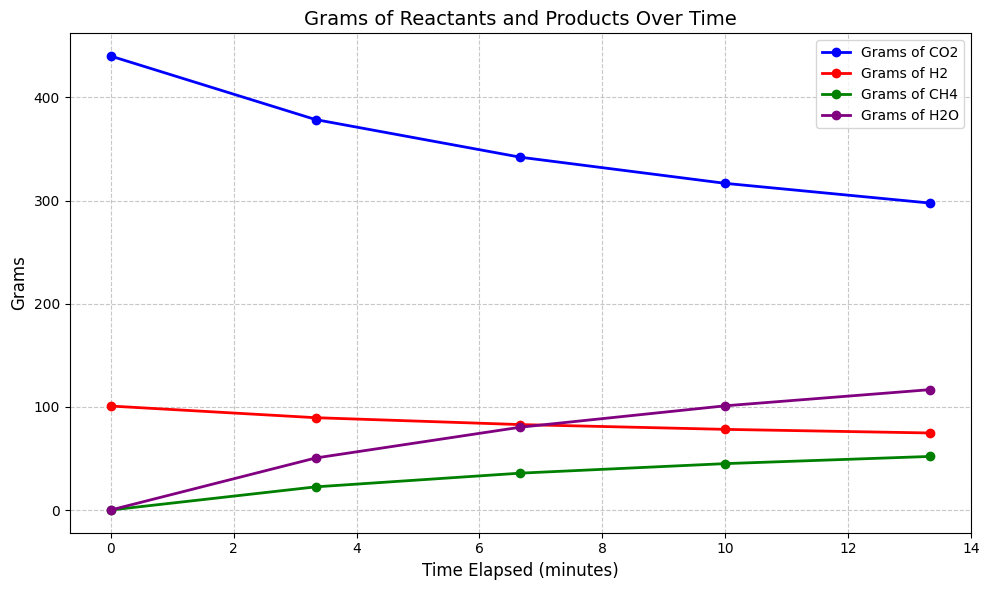

In [ ]:
plt.figure(figsize=(10, 6))
sampled_df = df[::20]
sampled_df["time_elapsed_minutes"] = sampled_df["time_elapsed_second"] / 60
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["CO2_g"], label="Grams of CO2", color="blue", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["H2_g"], label="Grams of H2", color="red", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["CH4_g"], label="Grams of CH4", color="green", linewidth=2, marker="o")
plt.plot(sampled_df["time_elapsed_minutes"], sampled_df["H2O_g"], label="Grams of H2O", color="purple", linewidth=2, marker="o")
plt.title("Grams of Reactants and Products Over Time", fontsize=14)
plt.xlabel("Time Elapsed (minutes)", fontsize=12)
plt.ylabel("Grams", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("static/images/methanation_sim_level_3_moles_to_grams.png", dpi=300)
plt.show()

In [14]:
df.columns

Index(['time_elapsed_second', 'rate_constant_mole_per_second',
       'current_rate_meter_pow_12_per_mole_pow_4_per_second', 'CO2_mole',
       'H2_mole', 'CH4_mole', 'H2O_mole', 'total_consumed_CO2_mole',
       'total_consumed_H2_mole', 'total_produced_CH4_mole',
       'total_produced_H2O_mole', 'reactor_type', 'reactor_volume_meter_cubed',
       'temperature_kelvin', 'activation_energy_joule_per_mole',
       'pre_exponential_meter_pow_12_per_mole_pow_4_per_second',
       'volumetric_flow_rate_meter_cubed_per_second',
       'arrhenius_rate_constant_meter_pow_12_per_mole_pow_4_per_second',
       'current_reaction_rate_mole_per_meter_cubed_per_second',
       'inlet_flow_CO2_mole_per_second', 'inlet_flow_H2_mole_per_second',
       'energy_balance', 'pressure_drop', 'reversible_kinetics',
       'inlet_temperature_kelvin', 'inlet_pressure_pascal',
       'outlet_temperature_kelvin', 'outlet_pressure_pascal',
       'heat_of_reaction_joule_per_mole',
       'heat_capacity_joule_pe

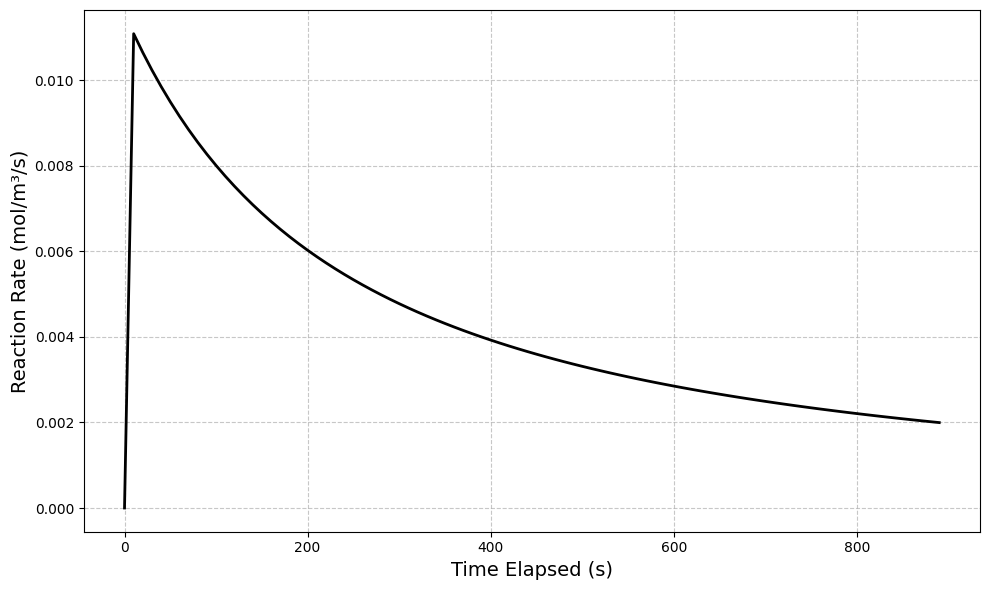

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.current_reaction_rate_mole_per_meter_cubed_per_second, color='black', linewidth=2)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Reaction Rate (mol/m³/s)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

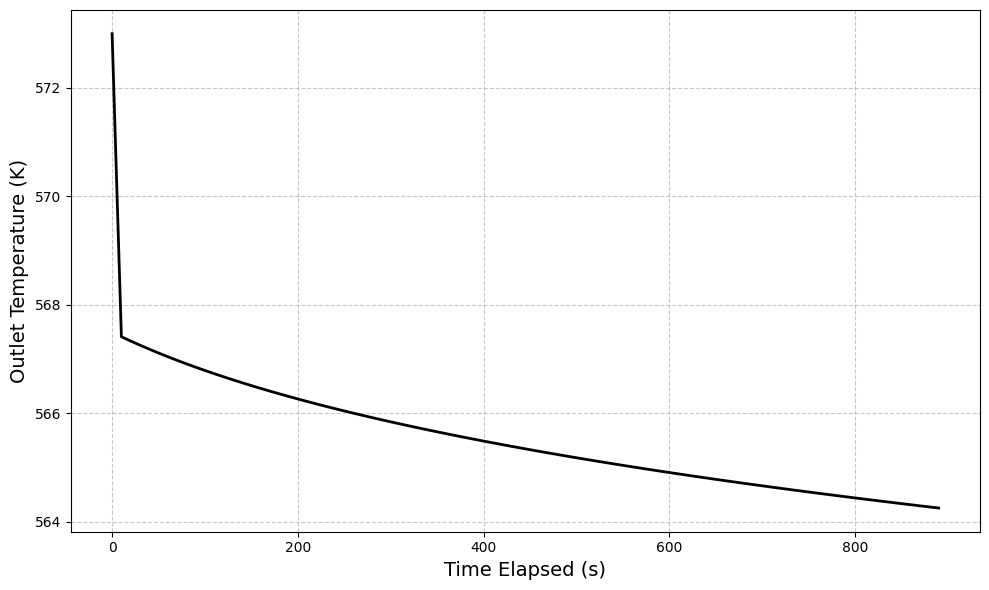

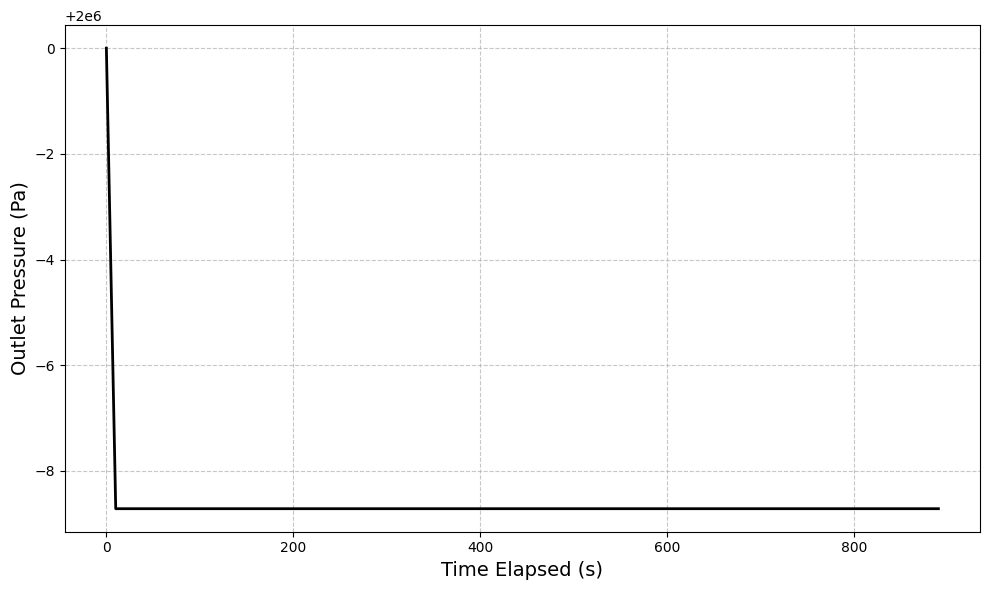

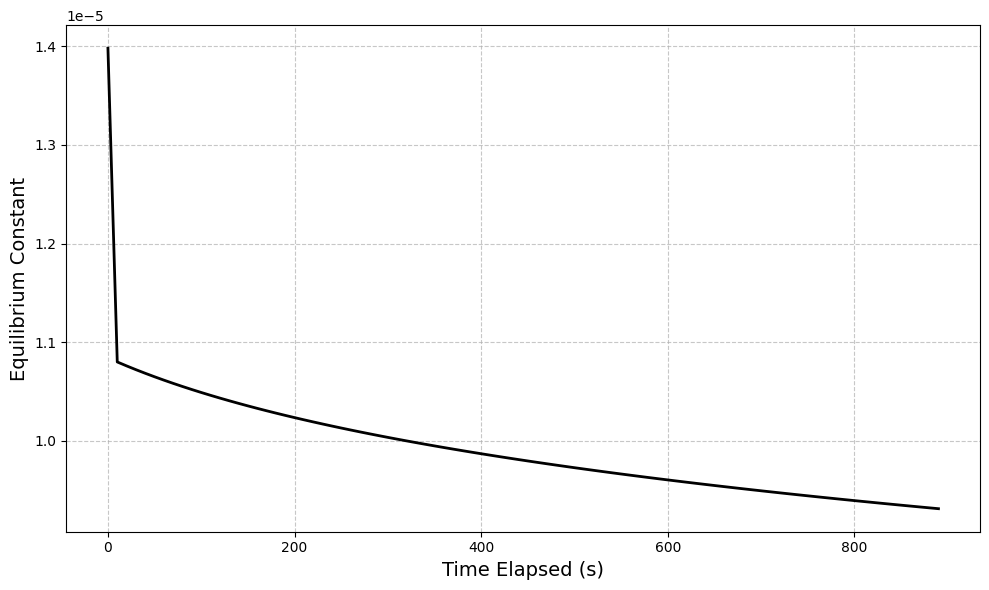

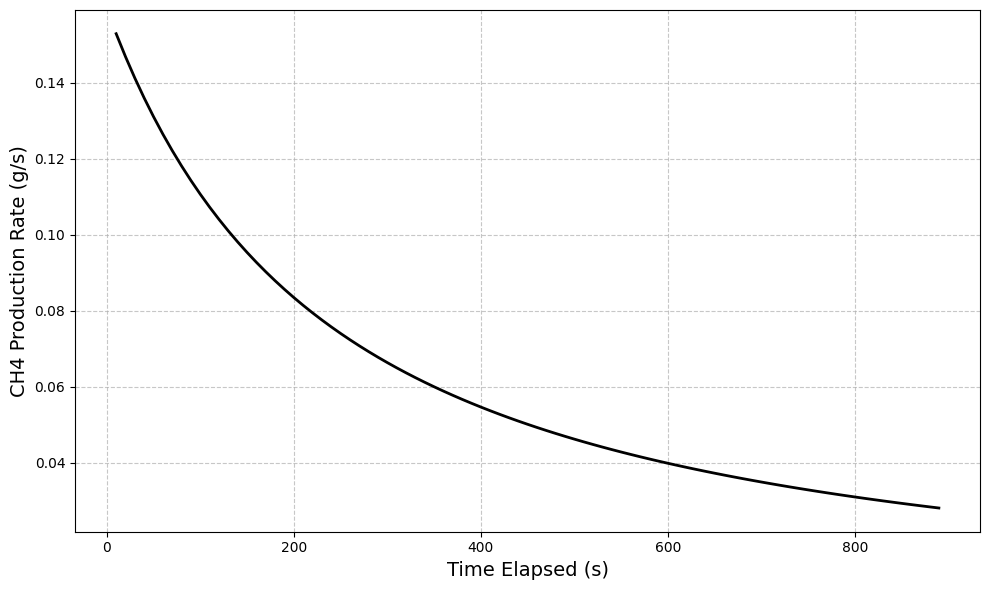

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.outlet_temperature_kelvin, color='black', linewidth=2)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Outlet Temperature (K)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df.outlet_pressure_pascal, color='black', linewidth=2)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Outlet Pressure (Pa)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df.equilibrium_constant, color='black', linewidth=2)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("Equilibrium Constant", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df.index, df.CH4_production_rate_g_per_s, color='black', linewidth=2)
plt.xlabel("Time Elapsed (s)", fontsize=14)
plt.ylabel("CH4 Production Rate (g/s)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()